In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, f1_score, roc_auc_score

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

import pickle

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

In [ ]:
#Reading the data
df = pd.concat(
    [
        pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2321004016_VuNgocLinh_DoAn/data/customer_churn_dataset-training-master.csv'),
        pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2321004016_VuNgocLinh_DoAn/data/customer_churn_dataset-testing-master.csv')
    ],
    axis=0)
df.reset_index(drop=True, inplace=True)
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
505202,64370.0,45.0,Female,33.0,12.0,6.0,21.0,Basic,Quarterly,947.0,14.0,1.0
505203,64371.0,37.0,Male,6.0,1.0,5.0,22.0,Standard,Annual,923.0,9.0,1.0
505204,64372.0,25.0,Male,39.0,14.0,8.0,30.0,Premium,Monthly,327.0,20.0,1.0
505205,64373.0,50.0,Female,18.0,19.0,7.0,22.0,Standard,Monthly,540.0,13.0,1.0


In [ ]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
df.describe(include=[object])

,Gender,Subscription Type,Contract Length
count,505206,505206,505206
unique,2,3,3
top,Male,Standard,Annual
freq,280273,170630,198608


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 46.3+ MB


In [ ]:
df.drop(columns='CustomerID', inplace=True) # removing unnecessary colum

df.columns = [col.lower().replace(' ', '_') for col in df.columns]

In [ ]:
df.shape

(505207, 11)

In [ ]:
df.isnull().sum()

,0
age,1
gender,1
tenure,1
usage_frequency,1
support_calls,1
payment_delay,1
subscription_type,1
contract_length,1
total_spend,1
last_interaction,1


In [ ]:
df[df.isna().any(axis=1)]

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(505206, 11)

In [ ]:
descrete_col = ['age', 'tenure', 'usage_frequency', 'support_calls', 'payment_delay', 'last_interaction', 'churn']
for col in descrete_col:
    df[col] = df[col].astype(int)
df

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn
0,30,Female,39,14,5,18,Standard,Annual,932.0,17,1
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6,1
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3,1
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29,1
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20,1
...,...,...,...,...,...,...,...,...,...,...,...
505202,45,Female,33,12,6,21,Basic,Quarterly,947.0,14,1
505203,37,Male,6,1,5,22,Standard,Annual,923.0,9,1
505204,25,Male,39,14,8,30,Premium,Monthly,327.0,20,1
505205,50,Female,18,19,7,22,Standard,Monthly,540.0,13,1


In [ ]:
# Creating custom functions to visualize features

def make_histogram(df, target_feature, bins = 10, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    plt.hist(df[target_feature], bins=bins)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.ylabel('Count')
    plt.xlabel(target_feature)
    plt.title(f"Distribution of {target_feature.lower()}{additional}:\n")
    plt.grid()
    plt.show()
    print(f"Distribution of {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n{df[target_feature].skew():.3f} Skewness\n")

def make_piechart(df, target_feature, additional=''):
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())

    palette_color = sns.color_palette('bright')
    plt.pie(data, labels=keys, colors=palette_color, autopct='%.0f%%')
    plt.title(f"Distribution of Cutomer's {target_feature}:")
    plt.show()
    print_str = f"Distribution of cutomer's {target_feature.lower()}{additional}:"
    for k, v in zip(keys, data):
        print_str += f"\n{v} {k}"
    print(print_str)

def make_barplot(df, target_feature, custom_ticks=None, unit='', additional=''):
    plt.figure(figsize=(10, 5))
    dict_of_val_counts = dict(df[target_feature].value_counts())
    data = list(dict_of_val_counts.values())
    keys = list(dict_of_val_counts.keys())
    plt.bar(keys, data)
    if custom_ticks is not None:
        plt.xticks(custom_ticks)
    plt.xlabel(f'{target_feature.capitalize()}{additional}')
    plt.ylabel('Frequency')
    plt.title(f"Distribution of cutomer's {target_feature.lower()}{additional}\n")
    plt.grid(axis='y')
    plt.show()
    print(f"Distribution of cutomer's {target_feature.lower()}{additional}: {df[target_feature].mean():.2f} ± {df[target_feature].median():.2f} {unit}\nMedian: {df[target_feature].median():.2f} {unit}\nMinimum: {df[target_feature].min()} {unit}\nMaximum: {df[target_feature].max()} {unit}\n\n{df[target_feature].skew():.3f} Skewness\n")

def make_boxplot(df, feature):
    plt.figure(figsize=(10,5))
    sns.boxplot(df, x=feature)
    plt.title(f"Boxplot of {feature}\n")
    plt.xlabel(feature)
    plt.ylabel("Values")
    plt.show()

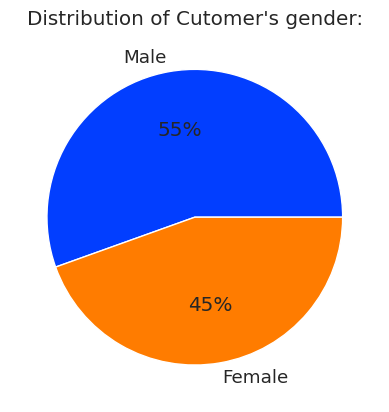

Distribution of cutomer's gender:
280273 Male
224933 Female


In [ ]:
make_piechart(df, 'gender')

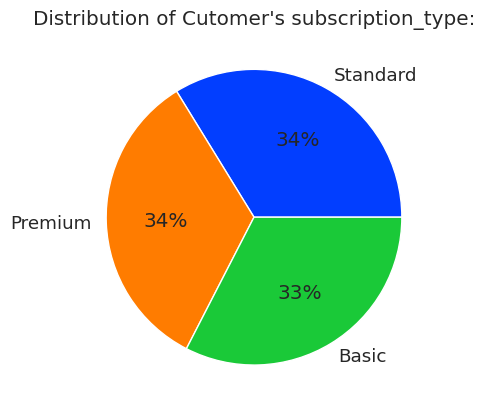

Distribution of cutomer's subscription_type:
170630 Standard
170099 Premium
164477 Basic


In [ ]:
make_piechart(df, 'subscription_type')


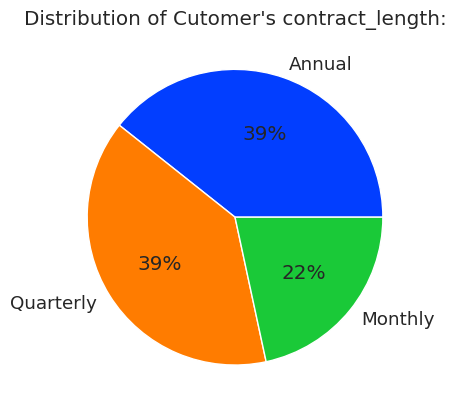

Distribution of cutomer's contract_length:
198608 Annual
197364 Quarterly
109234 Monthly


In [ ]:
make_piechart(df, 'contract_length')

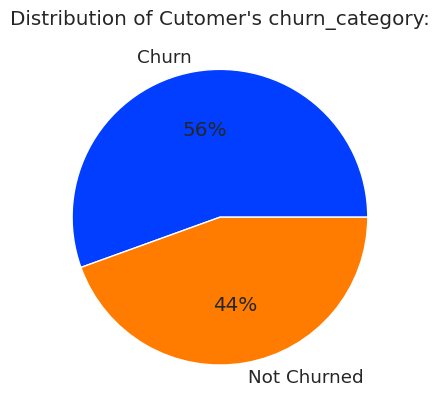

Distribution of cutomer's churn_category:
280492 Churn
224714 Not Churned


In [ ]:
filtered = df.copy()
filtered['churn_category'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]
make_piechart(filtered, 'churn_category')

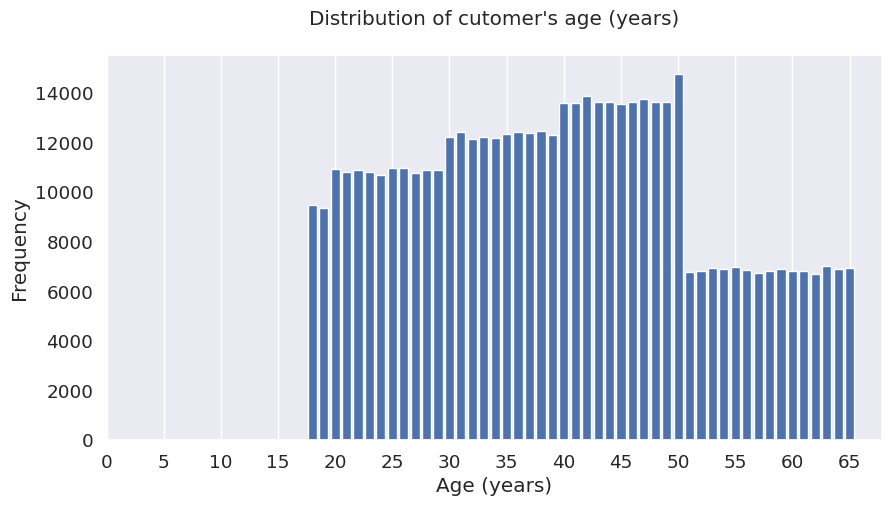

Distribution of cutomer's age (years): 39.70 ± 40.00 years
Median: 40.00 years
Minimum: 18 years
Maximum: 65 years

0.144 Skewness



In [ ]:
make_barplot(df, 'age', custom_ticks=np.arange(0, 66, 5), additional=' (years)', unit='years')

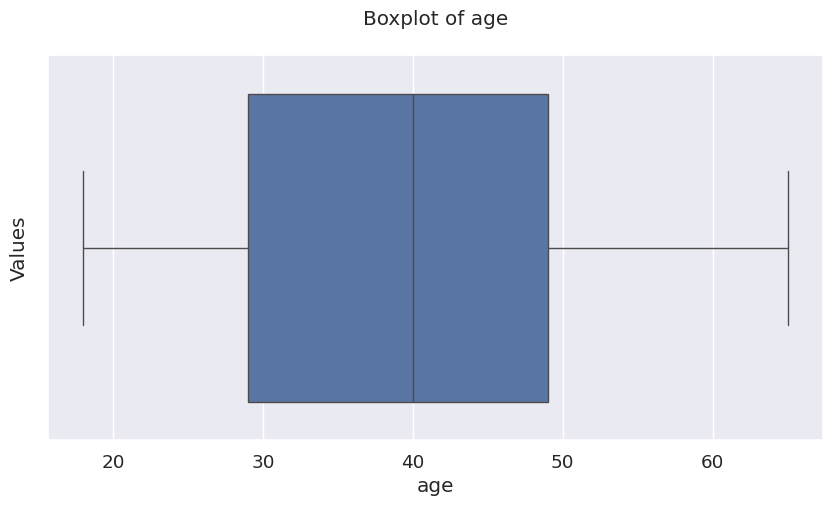

In [ ]:
make_boxplot(df, 'age')

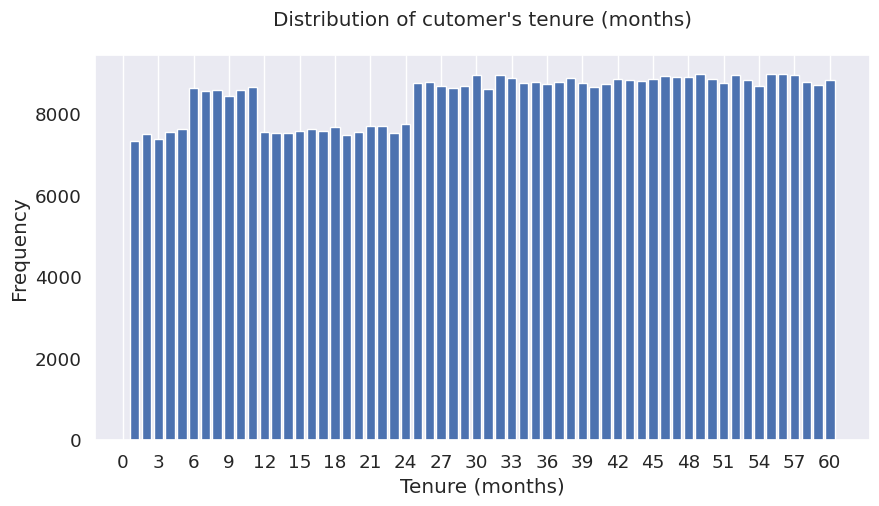

Distribution of cutomer's tenure (months): 31.35 ± 32.00 months
Median: 32.00 months
Minimum: 1 months
Maximum: 60 months

-0.070 Skewness



In [ ]:
make_barplot(df, 'tenure', custom_ticks=np.arange(0, 61, 3), additional=' (months)', unit='months')

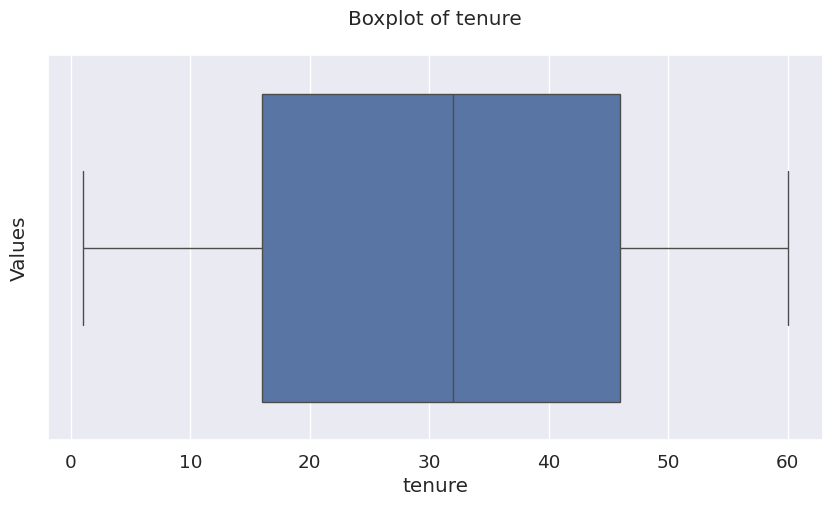

In [ ]:
make_boxplot(df, 'tenure')

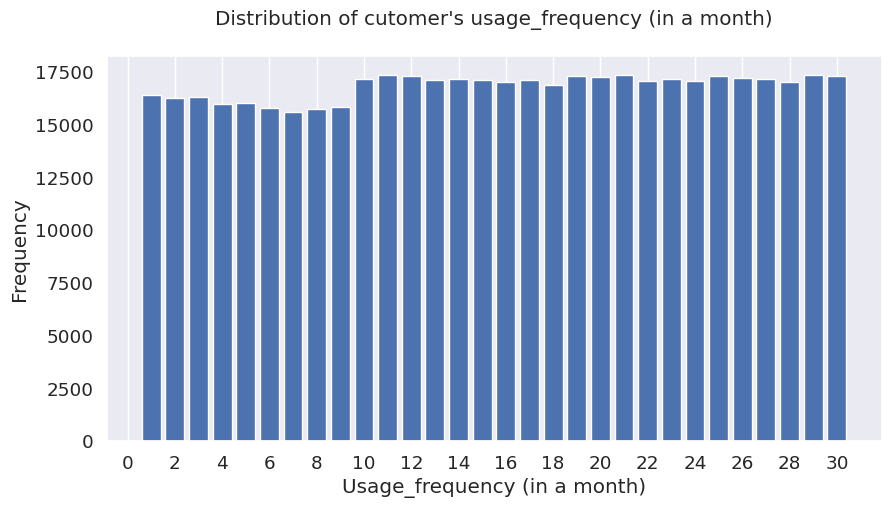

Distribution of cutomer's usage_frequency (in a month): 15.71 ± 16.00 times
Median: 16.00 times
Minimum: 1 times
Maximum: 30 times

-0.034 Skewness



In [ ]:
make_barplot(df, 'usage_frequency', custom_ticks=np.arange(0, 31, 2), unit='times', additional=' (in a month)')

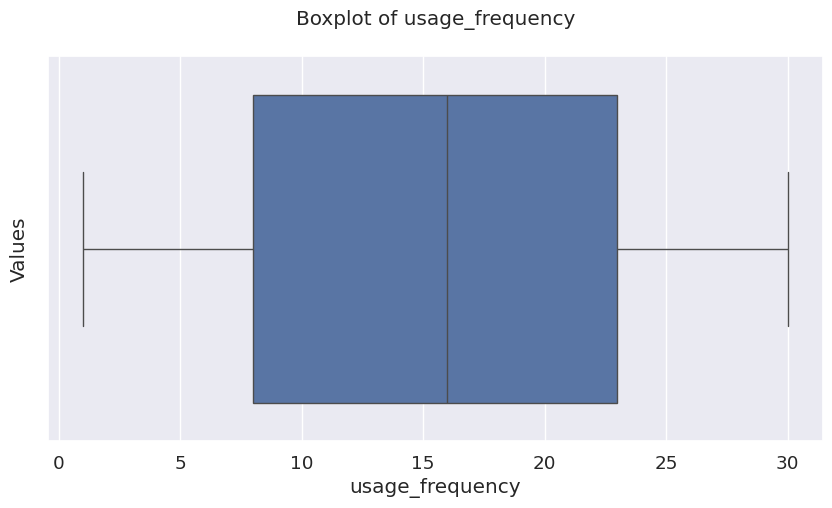

In [ ]:
make_boxplot(df, 'usage_frequency')

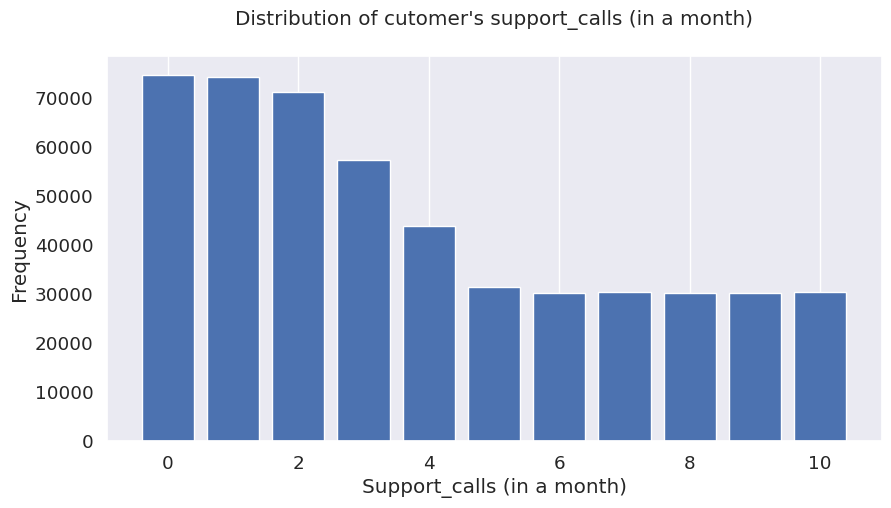

Distribution of cutomer's support_calls (in a month): 3.83 ± 3.00 calls
Median: 3.00 calls
Minimum: 0 calls
Maximum: 10 calls

0.544 Skewness



In [ ]:
make_barplot(df, 'support_calls', unit='calls', additional=' (in a month)')

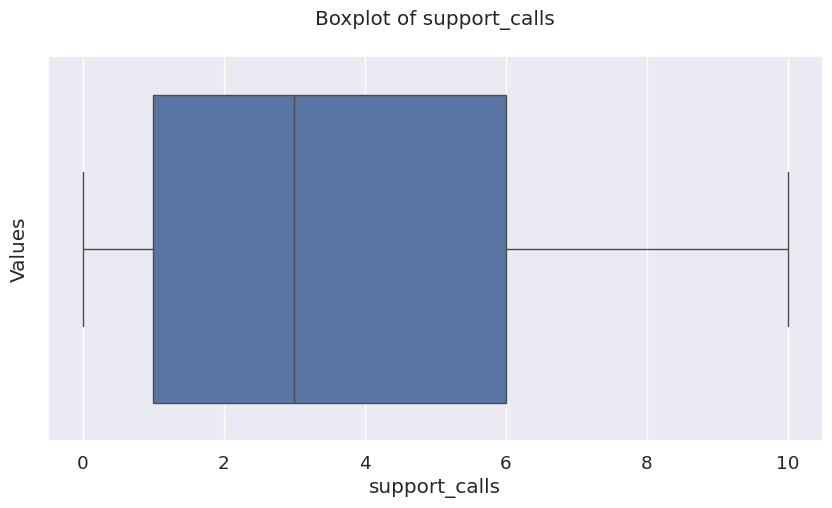

In [ ]:
make_boxplot(df, 'support_calls')

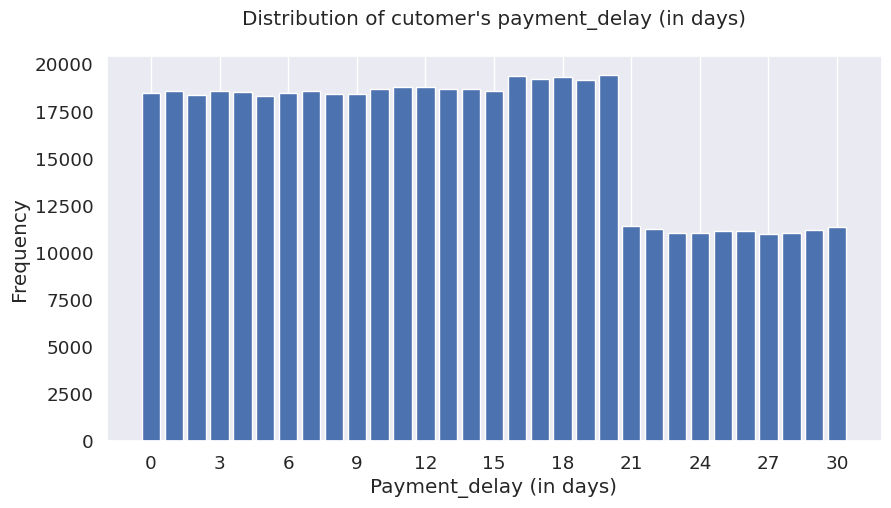

Distribution of cutomer's payment_delay (in days): 13.50 ± 13.00 days
Median: 13.00 days
Minimum: 0 days
Maximum: 30 days

0.200 Skewness



In [ ]:
make_barplot(df, 'payment_delay', custom_ticks=np.arange(0, 32, 3), unit='days', additional=' (in days)')

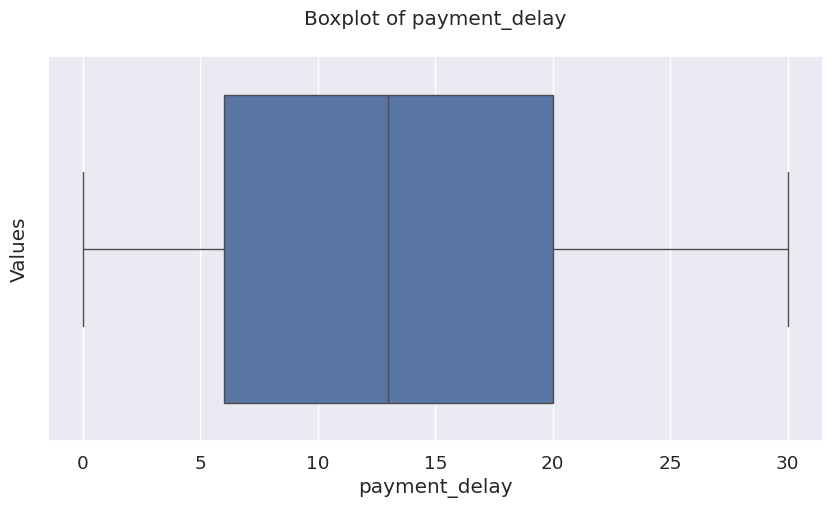

In [ ]:
make_boxplot(df, 'payment_delay')

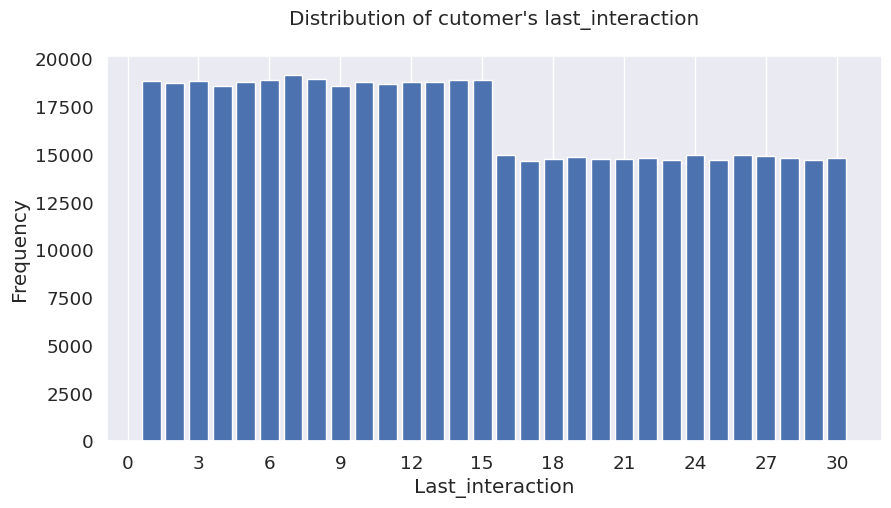

Distribution of cutomer's last_interaction: 14.61 ± 14.00 days
Median: 14.00 days
Minimum: 1 days
Maximum: 30 days

0.155 Skewness



In [ ]:
make_barplot(df, 'last_interaction', custom_ticks=np.arange(0, 32, 3), unit='days', additional='')

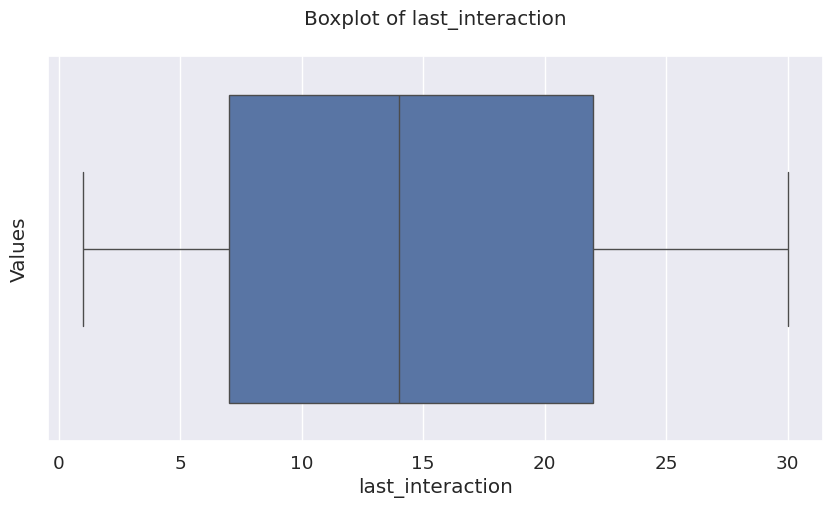

In [ ]:
make_boxplot(df, 'last_interaction')

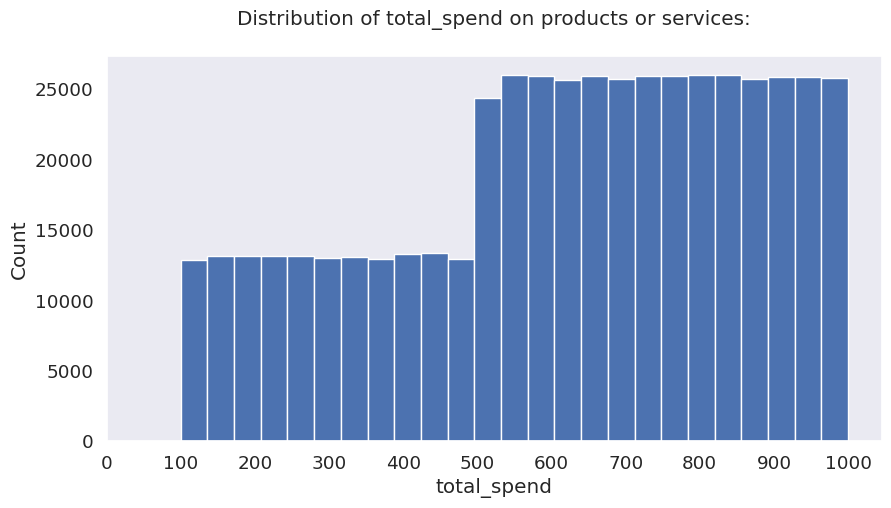

Distribution of total_spend on products or services: 620.07 ± 648.90 USD
Median: 648.90 USD
Minimum: 100.0 USD
Maximum: 1000.0 USD
-0.395 Skewness



In [ ]:
make_histogram(df, 'total_spend', bins=25, custom_ticks=np.arange(0, 1001, 100), unit='USD', additional=" on products or services")

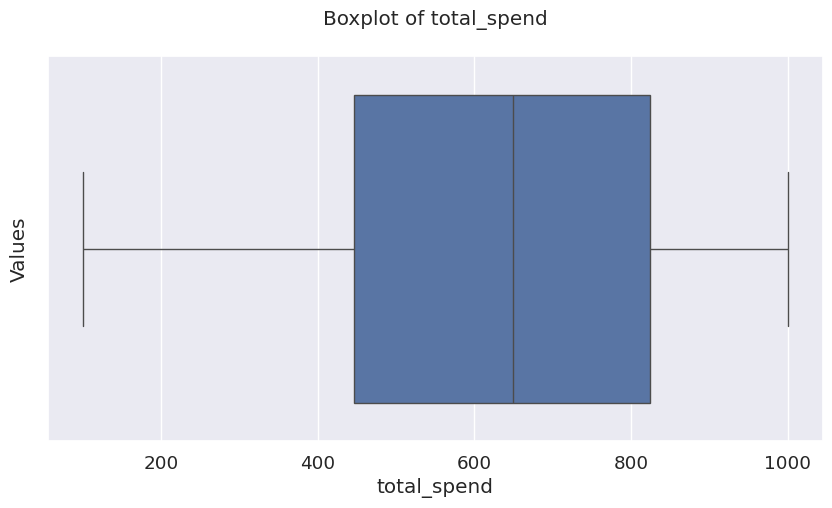

In [ ]:
make_boxplot(df, 'total_spend')

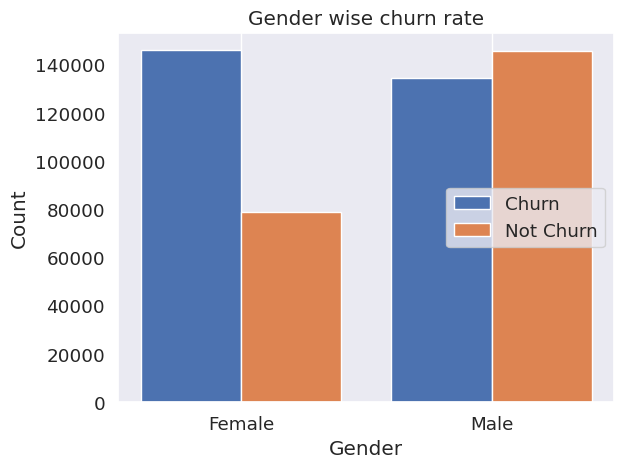

In [ ]:
gender_churn = df.groupby(['gender', 'churn']).size().unstack()

X = list(gender_churn.index)
churn_0 = list(gender_churn.iloc[:, 0])
churn_1 = list(gender_churn.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title("Gender wise churn rate")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

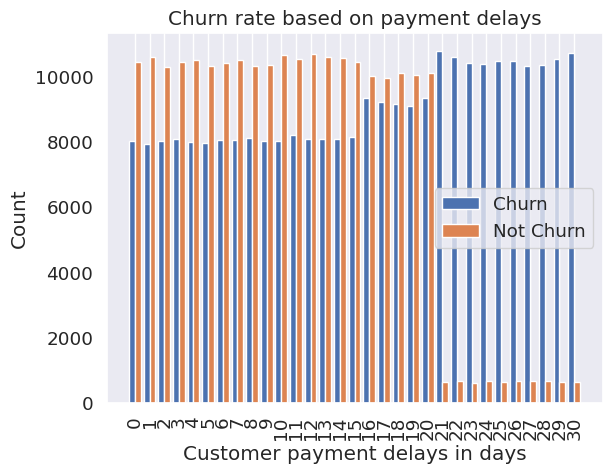

In [ ]:
filtered = df.groupby(['payment_delay', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer payment delays in days")
plt.ylabel('Count')
plt.title("Churn rate based on payment delays")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

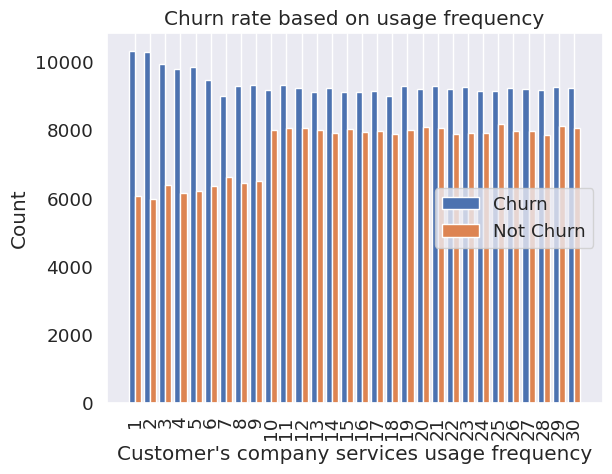

In [ ]:
filtered = df.groupby(['usage_frequency', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=90)
plt.xlabel("Customer's company services usage frequency")
plt.ylabel('Count')
plt.title("Churn rate based on usage frequency")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

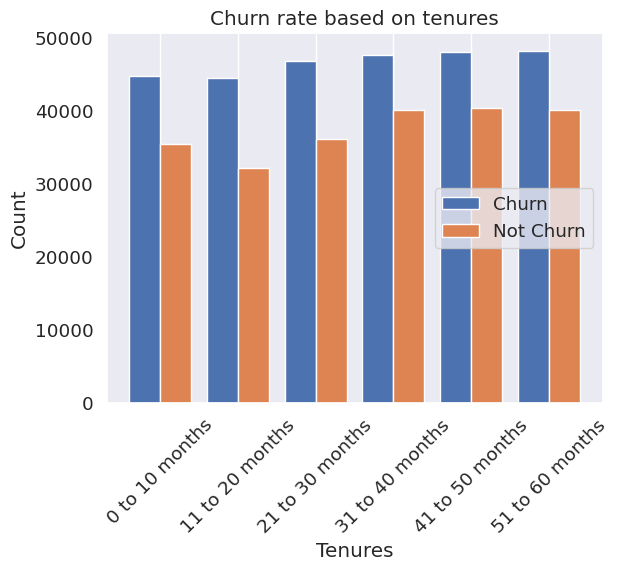

In [ ]:
def categorize_age(age):
    if 0 <= age <= 10:
        return '0 to 10 months'
    elif 11 <= age <= 20:
        return '11 to 20 months'
    elif 21 <= age <= 30:
        return '21 to 30 months'
    elif 31 <= age <= 40:
        return '31 to 40 months'
    elif 41 <= age <= 50:
        return '41 to 50 months'
    elif 51 <= age <= 60:
        return '51 to 60 months'
    else:
        pass # For nan values

filtered = df.copy()
filtered['tenure_segmentation'] = df['tenure'].apply(categorize_age)
filtered = filtered.groupby(['tenure_segmentation', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Tenures')
plt.ylabel('Count')
plt.title("Churn rate based on tenures")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

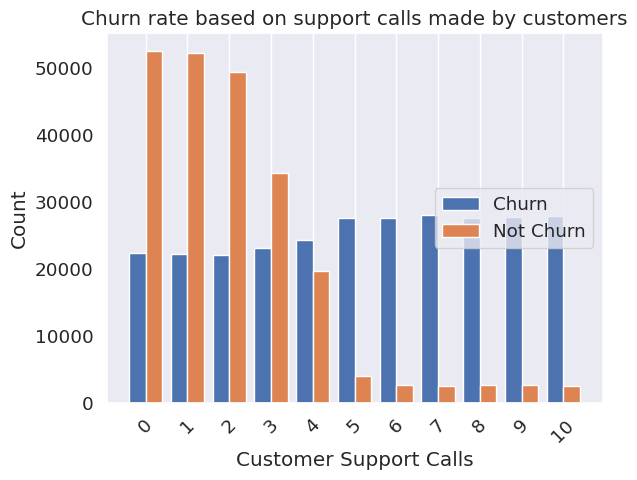

In [ ]:
filtered = df.groupby(['support_calls', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Customer Support Calls')
plt.ylabel('Count')
plt.title("Churn rate based on support calls made by customers")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

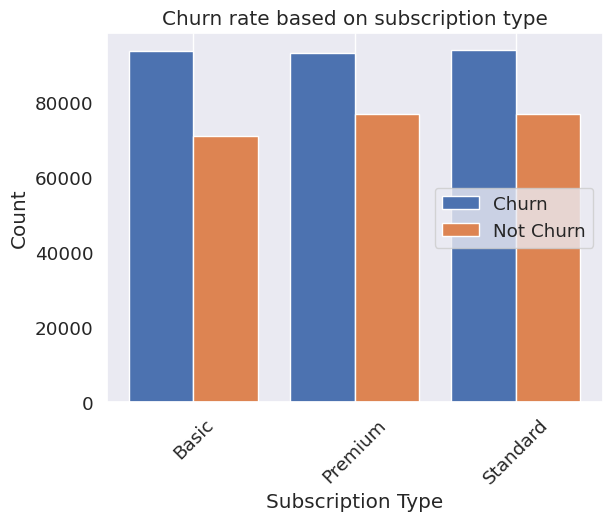

In [ ]:
filtered = df.groupby(['subscription_type', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.title("Churn rate based on subscription type")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

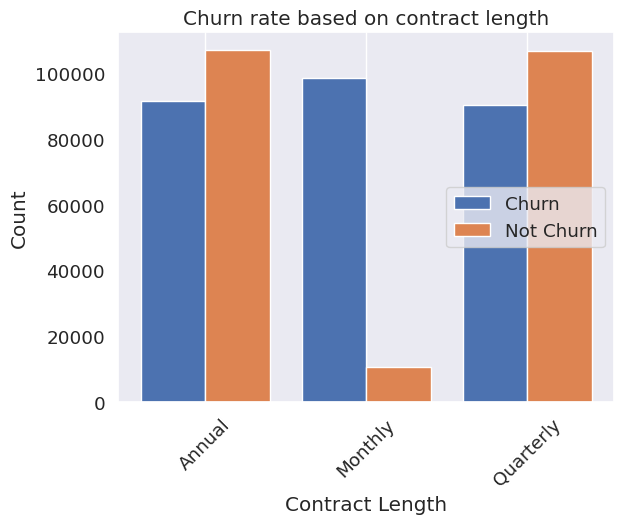

In [ ]:
filtered = df.groupby(['contract_length', 'churn']).size().unstack()

X = list(filtered.index)
churn_0 = list(filtered.iloc[:, 0])
churn_1 = list(filtered.iloc[:, 1])

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, churn_1, 0.4, label = 'Churn')
plt.bar(X_axis + 0.2, churn_0, 0.4, label = 'Not Churn')

plt.xticks(X_axis, X, rotation=45)
plt.xlabel('Contract Length')
plt.ylabel('Count')
plt.title("Churn rate based on contract length")
plt.legend(loc='center right')
plt.grid(axis='y')
plt.show()

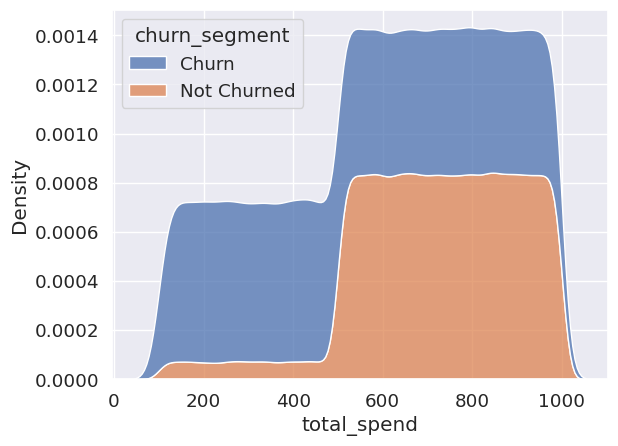

In [ ]:
filtered = df.copy()
filtered['churn_segment'] = ['Churn' if x == 1.0 else 'Not Churned' for x in df['churn']]

sns.kdeplot(data=filtered, x="total_spend", hue="churn_segment", multiple="stack")
plt.show()


In [ ]:
independent_features_df = df.select_dtypes(include=['number']).copy().drop(columns=['churn'])

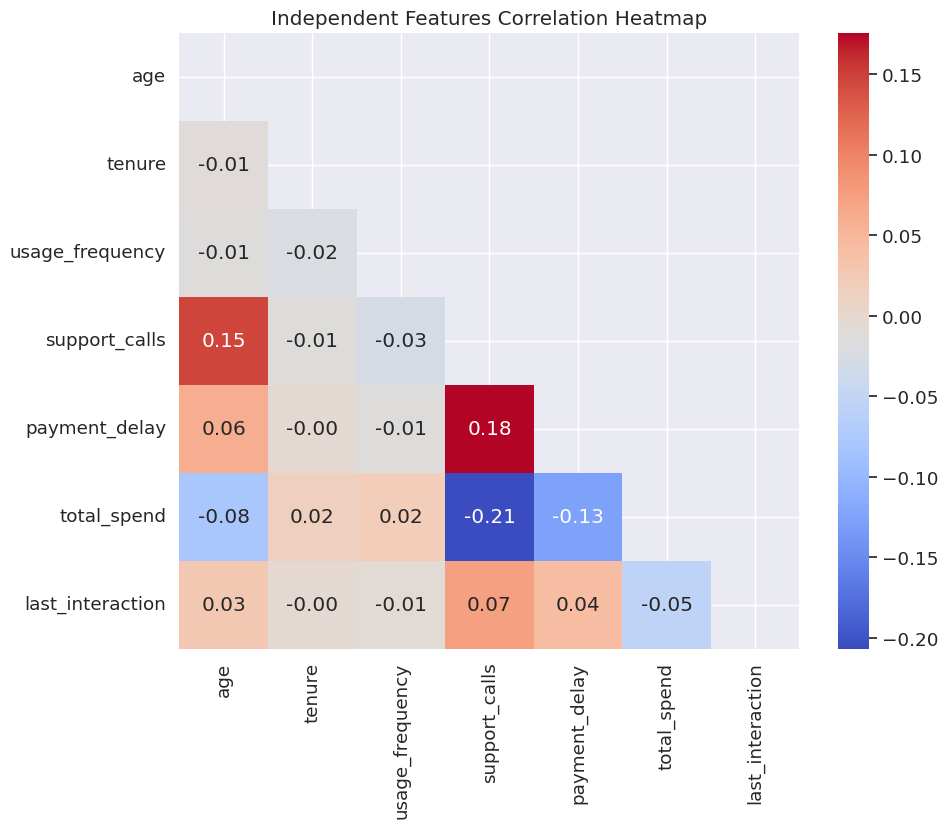

In [ ]:
corr_matrix = independent_features_df.corr()

# Creating a mask to hide the upper triangle of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
plt.title("Independent Features Correlation Heatmap")
plt.show()

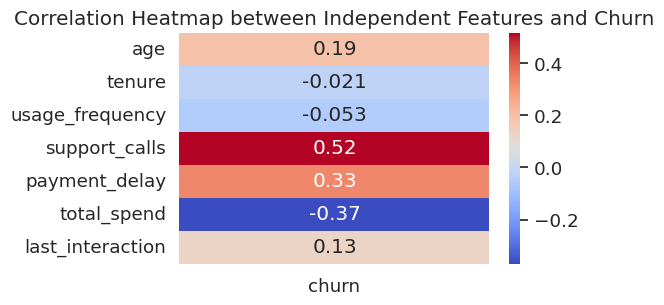

In [ ]:
correlation_data = df.select_dtypes(include=['number']).corr().loc[:'last_interaction', 'churn']


# Create a heatmap
plt.figure(figsize=(5, 3))
sns.set(font_scale=1.2)
sns.heatmap(correlation_data.to_frame(), annot=True, cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap between Independent Features and Churn")
plt.show()

In [ ]:
df[df.duplicated()]

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction,churn


In [ ]:
y = df['churn']
X = df.drop(columns='churn')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Reset the index of the resulting DataFrames
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

In [ ]:
X_train

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction
0,19,Female,48,7,3,30,Premium,Annual,787.00,29
1,65,Female,11,20,9,14,Standard,Monthly,562.00,13
2,38,Male,8,20,1,4,Basic,Quarterly,961.86,8
3,38,Female,59,25,10,4,Premium,Annual,706.00,14
4,46,Male,38,24,10,16,Standard,Annual,260.00,25
...,...,...,...,...,...,...,...,...,...,...
404159,24,Female,1,4,2,18,Standard,Quarterly,740.72,15
404160,62,Male,29,23,9,24,Standard,Quarterly,327.10,11
404161,34,Male,13,16,1,6,Premium,Quarterly,520.36,23
404162,35,Male,23,18,4,10,Standard,Monthly,420.00,3


In [ ]:
X_test

,age,gender,tenure,usage_frequency,support_calls,payment_delay,subscription_type,contract_length,total_spend,last_interaction
0,58,Male,2,20,6,24,Standard,Quarterly,664.00,20
1,52,Male,14,13,2,13,Standard,Monthly,650.00,9
2,46,Male,38,3,0,9,Basic,Annual,571.47,24
3,29,Female,59,27,5,22,Basic,Quarterly,502.00,2
4,42,Male,29,7,1,20,Basic,Annual,541.34,10
...,...,...,...,...,...,...,...,...,...,...
101037,29,Male,33,9,1,1,Basic,Annual,801.41,29
101038,34,Male,43,28,9,11,Standard,Annual,435.00,30
101039,50,Female,40,13,0,1,Premium,Quarterly,651.28,9
101040,49,Female,46,6,0,20,Standard,Quarterly,897.68,2


In [ ]:
def validate_test_data_categorical_columns(train_df, test_df):
    # Get the list of categorical columns for both train and test DataFrames
    train_df_categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
    test_df_categorical_columns = test_df.select_dtypes(include=['object', 'category']).columns.tolist()

    # Check if the number of categorical columns is the same in both DataFrames
    if len(set(train_df_categorical_columns).intersection(set(test_df_categorical_columns))) == 0:
        print('Train and test dataframes have different categorical columns')
        return
    else:
        for cat_col in test_df_categorical_columns:
            # Create sets of unique values for the current categorical column in both DataFrames
            train_col = set(x for x in train_df[cat_col].unique().tolist() if not pd.isna(x))
            test_col = set(x for x in test_df[cat_col].unique().tolist() if not pd.isna(x))

            # Check if the sets are not equal, indicating different unique values
            if train_col != test_col:
                print(f'{cat_col} column has different unique values in train and test data:')
                print(f'Unique values in train data: {train_col}')
                print(f'Unique values in test data: {test_col}')
                return

        print('All categorical columns have consistent unique values in train and test data.')
        return

validate_test_data_categorical_columns(X_train, X_test)

All categorical columns have consistent unique values in train and test data.


In [ ]:
encoder = OneHotEncoder(sparse_output=False)

encoder.fit(X_train[['gender', 'subscription_type', 'contract_length']])

OneHotEncoder(sparse_output=False)

In [ ]:
feature_names = encoder.get_feature_names_out(['gender', 'subscription_type', 'contract_length'])
feature_names

array(['gender_Female', 'gender_Male', 'subscription_type_Basic',
       'subscription_type_Premium', 'subscription_type_Standard',
       'contract_length_Annual', 'contract_length_Monthly',
       'contract_length_Quarterly'], dtype=object)

In [ ]:
train_categorical_one_encoded_data = encoder.transform(X_train[['gender', 'subscription_type', 'contract_length']])
train_OHE_df = pd.DataFrame(train_categorical_one_encoded_data, columns=feature_names)

test_categorical_one_encoded_data = encoder.transform(X_test[['gender', 'subscription_type', 'contract_length']])
test_OHE_df = pd.DataFrame(test_categorical_one_encoded_data, columns=feature_names)

In [ ]:
train_OHE_df.head(3)

,gender_Female,gender_Male,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
test_OHE_df.head(3)


,gender_Female,gender_Male,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
X_train = X_train.drop(columns=['gender', 'subscription_type', 'contract_length'])
X_test = X_test.drop(columns=['gender', 'subscription_type', 'contract_length'])

In [ ]:
X_train.head(3)

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction
0,19,48,7,3,30,787.00,29
1,65,11,20,9,14,562.00,13
2,38,8,20,1,4,961.86,8


In [ ]:
X_test.head(3)

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction
0,58,2,20,6,24,664.00,20
1,52,14,13,2,13,650.00,9
2,46,38,3,0,9,571.47,24


In [ ]:
X_train = pd.concat([X_train, train_OHE_df], axis=1)
X_test = pd.concat([X_test, test_OHE_df], axis=1)

In [ ]:
X_train.head(3)

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,gender_Female,gender_Male,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,19,48,7,3,30,787.00,29,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,65,11,20,9,14,562.00,13,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,38,8,20,1,4,961.86,8,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
X_test.head(3)

,age,tenure,usage_frequency,support_calls,payment_delay,total_spend,last_interaction,gender_Female,gender_Male,subscription_type_Basic,subscription_type_Premium,subscription_type_Standard,contract_length_Annual,contract_length_Monthly,contract_length_Quarterly
0,58,2,20,6,24,664.00,20,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,52,14,13,2,13,650.00,9,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,46,38,3,0,9,571.47,24,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Saving the encoder to a file
with open('encoder.pkl', 'wb') as file:
    pickle.dump(encoder, file)

In [ ]:
# Example Usage

with open('encoder.pkl', 'rb') as file:
    loaded_encoder = pickle.load(file)

loaded_encoder.transform([['Male', 'Premium', 'Monthly']])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[0., 1., 0., 1., 0., 0., 1., 0.]])

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

In [ ]:
# Printing the explained variance ratio
pca.explained_variance_ratio_

array([0.98871624, 0.00488512])

In [ ]:
data = {
    'Feature_1': X_pca[:, 0],
    'Feature_2': X_pca[:, 1],
    'Target': y_train
}

pca_df = pd.DataFrame(data)
pca_df

,Feature_1,Feature_2,Target
0,166.666719,16.831219,1
1,-58.457548,-20.683890,0
2,341.575218,-23.661122,0
3,85.736400,27.466815,1
4,-360.378519,6.762457,1
...,...,...,...
404159,120.403395,-30.069073,0
404160,-293.360318,-2.462884,1
404161,-99.932907,-18.172059,0
404162,-200.272137,-8.057019,1


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


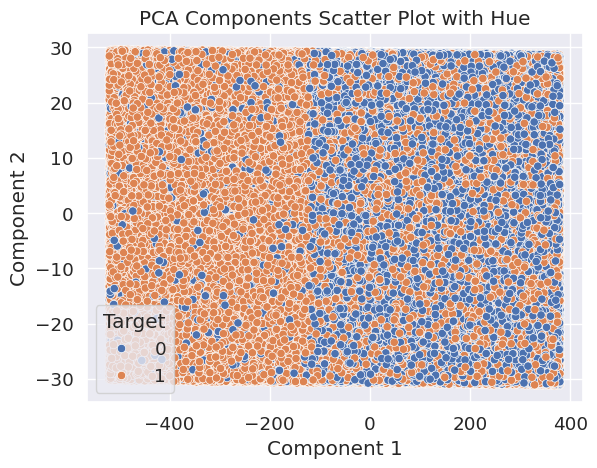

In [ ]:
sns.scatterplot(data=pca_df, x='Feature_1', y='Feature_2', hue='Target')

# Set plot labels and title
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('PCA Components Scatter Plot with Hue')

# Show the plot
plt.legend(title='Target')
plt.show()

In [ ]:
def print_evaluation_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print()

    conf_matrix = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(conf_matrix)
    print()

    class_report = classification_report(y_true, y_pred)
    print("Classification Report:")
    print(class_report)

In [ ]:
def k_fold_cross_validation_with_metrics(classifier, X, y, k_folds=5):

    # Initializing stratified k-fold cross-validation
    stratified_kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

    # Lists to store the evaluation metrics for each fold
    accuracy_scores = []
    precision_scores = []
    recall_scores = []

    # Perform cross-validation
    for train_index, test_index in stratified_kf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit the classifier on the training data
        classifier.fit(X_train, y_train)

        # Make predictions on the test data
        y_pred = classifier.predict(X_test)

        # Calculate evaluation metrics for this fold
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)

        # Append the metrics to their respective lists
        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)

    # Calculate and print the mean of each metric across all folds
    mean_accuracy = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)
    print("Mean Metrics Across Folds:")
    print(f"Mean Accuracy: {mean_accuracy:.2f}")
    print(f"Mean Precision: {mean_precision:.2f}")
    print(f"Mean Recall: {mean_recall:.2f}")

# Example usage:
# classifier = YourClassifier()  # Replace with your classifier of choice
# k_fold_cross_validation_with_metrics(classifier, X, y)

In [ ]:
random_forest_classifier = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10, min_samples_split=2, random_state=42)
k_fold_cross_validation_with_metrics(random_forest_classifier, X_train, y_train)

Mean Metrics Across Folds:
Mean Accuracy: 0.93
Mean Precision: 0.90
Mean Recall: 0.98


In [ ]:
decision_tree_classifier = DecisionTreeClassifier(random_state=42)
decision_tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Testing decision trees

y_pred = decision_tree_classifier.predict(X_test)

print_evaluation_metrics(y_test, y_pred)

Accuracy: 0.88
Precision: 0.90
Recall: 0.89

Confusion Matrix:
[[39468  5291]
 [ 6452 49831]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87     44759
           1       0.90      0.89      0.89     56283

    accuracy                           0.88    101042
   macro avg       0.88      0.88      0.88    101042
weighted avg       0.88      0.88      0.88    101042



In [ ]:
df_dt = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(df_dt.head())

,Actual,Predicted
0,1,0
1,1,1
2,0,0
3,1,1
4,0,0


# Confusion Matrix Visualization

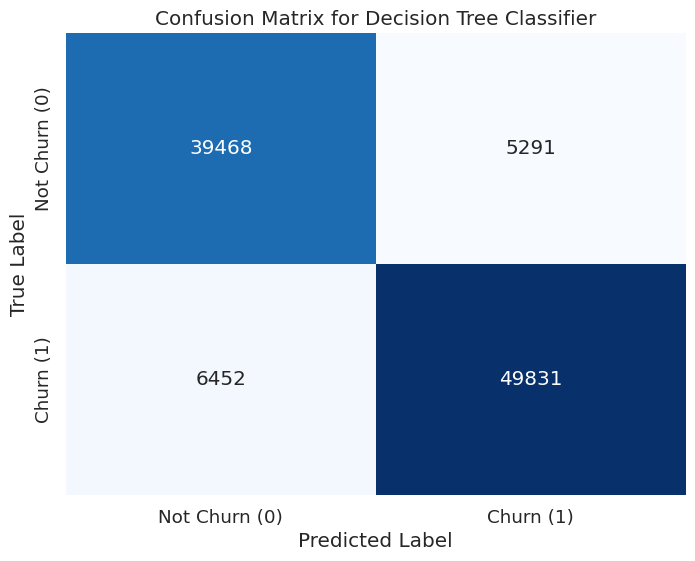

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

# Huấn luyện bằng mô hình Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RandomForest = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=10, min_samples_split=2)
RandomForest.fit(X_train,y_train)

RandomForestClassifier(max_depth=10)

In [ ]:
y_pred_randomforest = RandomForest.predict(X_test)

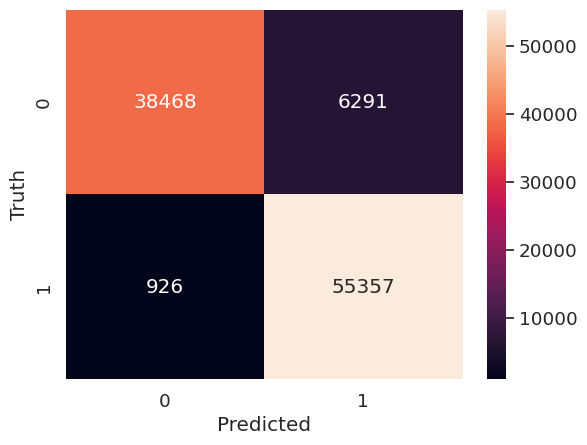

In [ ]:
# Đánh giá mô hình
cm = confusion_matrix(y_test,y_pred_randomforest)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [ ]:
print('Accuracy: ',accuracy_score(y_test,y_pred_randomforest))
print('Precision: ',precision_score(y_test,y_pred_randomforest))
print('Recall: ',recall_score(y_test,y_pred_randomforest))
print('F1 Score: ',f1_score(y_test,y_pred_randomforest))

Accuracy:  0.9285742562498763
Precision:  0.8979528938489488
Recall:  0.9835474299522058
F1 Score:  0.9388031984804673


In [ ]:
import os
import pickle
from sklearn.ensemble import RandomForestClassifier

# Define parameters that were reported as optimal from the previous GridSearch
optimal_params = {
    'n_estimators': 100,
    'criterion': 'gini',
    'max_depth': 15,
    'min_samples_leaf': 5,
    'min_samples_split': 5
}

# Try to load the grid_search object if it was saved
grid_search_path = 'grid_search.pkl'
if os.path.exists(grid_search_path):
    print(f"Loading grid_search object from {grid_search_path}...")
    with open(grid_search_path, 'rb') as f:
        grid_search = pickle.load(f)
    # Ensure best_estimator_ is available
    if not hasattr(grid_search, 'best_estimator_'):
        print("Loaded grid_search object does not have 'best_estimator_', creating one with optimal parameters.")
        grid_search.best_estimator_ = RandomForestClassifier(**optimal_params, random_state=42)
        grid_search.best_estimator_.fit(X_train, y_train) # Fit the best estimator for predictions
    else:
        # Ensure the loaded best_estimator_ is fitted
        if not hasattr(grid_search.best_estimator_, 'predict'):
             grid_search.best_estimator_.fit(X_train, y_train)
else:
    print(f"'{grid_search_path}' not found, creating a mock grid_search object with best_estimator_ using optimal parameters.")
    # Create a dummy object to mimic grid_search with best_estimator_
    class MockGridSearch:
        def __init__(self, estimator, params):
            self.best_estimator_ = estimator
            self.best_params_ = params

    best_rf_model = RandomForestClassifier(**optimal_params, random_state=42)
    best_rf_model.fit(X_train, y_train) # Fit the model to make predictions
    grid_search = MockGridSearch(best_rf_model, optimal_params)

# Now, use the best_estimator_ from grid_search to make predictions for the tuned model
y_pred_tune = grid_search.best_estimator_.predict(X_test)
rf_tune_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

print("Tuned Random Forest model prepared, y_pred_tune and rf_tune_proba defined.")

'grid_search.pkl' not found, creating a mock grid_search object with best_estimator_ using optimal parameters.
Tuned Random Forest model prepared, y_pred_tune and rf_tune_proba defined.


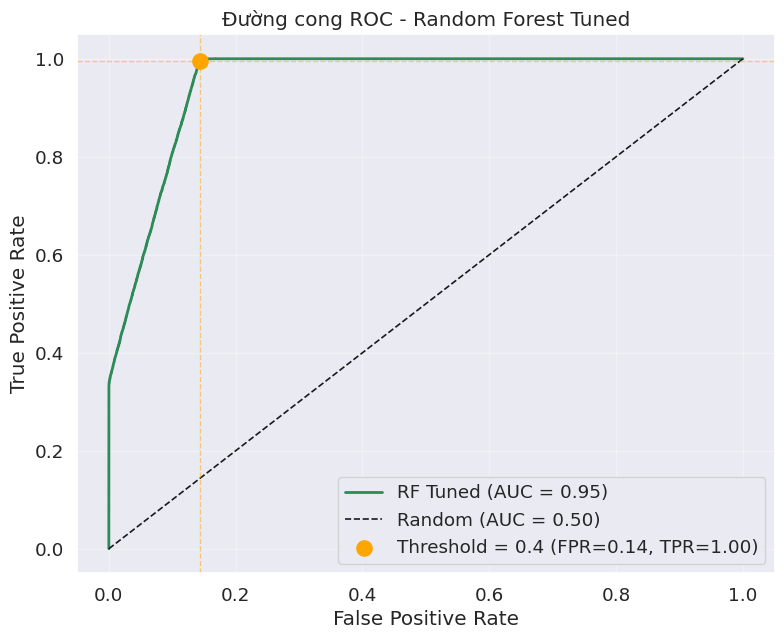

In [ ]:
#Vẽ đường cong ROC - Random Forest đã tune (GridSearch)

from sklearn.metrics import roc_curve, auc

# Lấy xác suất dự đoán từ mô hình đã tune
rf_tune_proba = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

# Tính ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_tune_proba)
roc_auc = auc(fpr, tpr)

# Tìm điểm hoạt động tại threshold = 0.4
idx_04 = np.argmin(np.abs(thresholds - 0.4))
op_fpr_04 = fpr[idx_04]
op_tpr_04 = tpr[idx_04]

# Dự đoán lại với threshold = 0.4
y_pred_tune_04 = (rf_tune_proba >= 0.4).astype(int)

# Vẽ đường cong ROC
plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='seagreen', lw=2,
         label=f'RF Tuned (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC = 0.50)')

# Đánh dấu điểm threshold = 0.4
plt.scatter(op_fpr_04, op_tpr_04, color='orange', zorder=5, s=120,
            label=f'Threshold = 0.4 (FPR={op_fpr_04:.2f}, TPR={op_tpr_04:.2f})')
plt.axvline(x=op_fpr_04, color='orange', linestyle='--', lw=1, alpha=0.5)
plt.axhline(y=op_tpr_04, color='orange', linestyle='--', lw=1, alpha=0.5)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường cong ROC - Random Forest Tuned')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

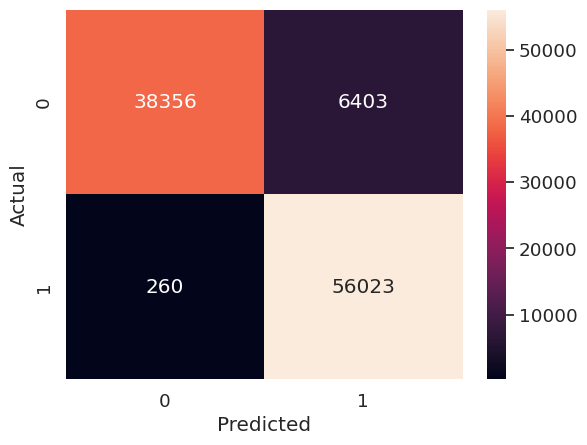

In [ ]:
#Ma trận nhầm lẫn sau khi thay đổi ngưỡng sang 0.4
cm_tune_04 = confusion_matrix(y_test, y_pred_tune_04)
sns.heatmap(cm_tune_04, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Đánh giá với threshold = 0.4
print('\n── Đánh giá RF Tuned tại threshold = 0.4 ──')
print('Accuracy: ', accuracy_score(y_test, y_pred_tune_04))
print('Precision:', precision_score(y_test, y_pred_tune_04))
print('Recall:   ', recall_score(y_test, y_pred_tune_04))
print('F1 Score: ', f1_score(y_test, y_pred_tune_04))


── Đánh giá RF Tuned tại threshold = 0.4 ──
Accuracy:  0.9340571247600008
Precision: 0.897430557780412
Recall:    0.9953804878915481
F1 Score:  0.943871147090785


# Đánh giá tầm quan trọng của các đặc trưng

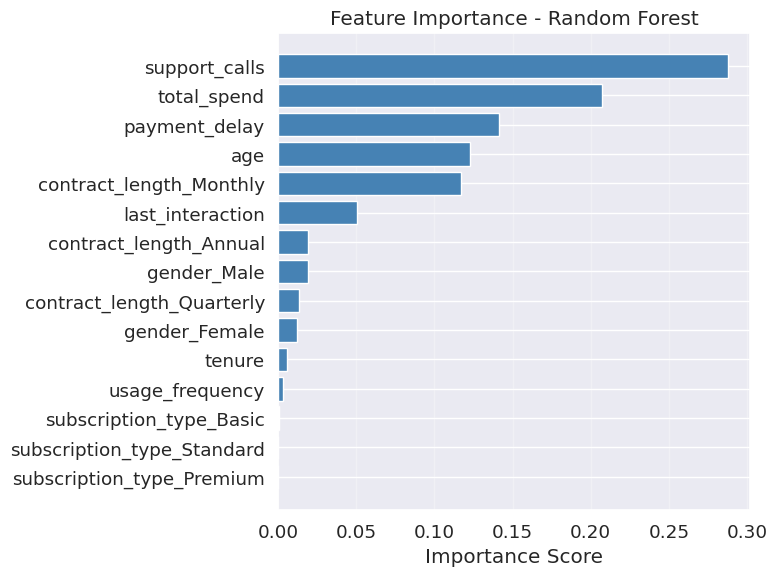

In [ ]:

#Vẽ biểu đồ các Feature Importance

# Lấy feature importance từ mô hình Random Forest
feature_importances = RandomForest.feature_importances_
feature_names = X_train.columns # Changed from X.columns to X_train.columns

# Tạo DataFrame và sắp xếp giảm dần
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(8, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

#Lập bảng so sánh các mô hình

models = ['Decision Tree', 'Random Forest (Base)', 'Random Forest (Tuned) ', 'Random Forest (Tuned - 0.4)']

# Tính toán các chỉ số cho từng mô hình
accs = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_randomforest),
    accuracy_score(y_test, y_pred_tune),
    accuracy_score(y_test, y_pred_tune_04)
]

precs = [
    precision_score(y_test, y_pred),
    precision_score(y_test, y_pred_randomforest),
    precision_score(y_test, y_pred_tune),
    precision_score(y_test, y_pred_tune_04)
]

recalls = [
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_randomforest),
    recall_score(y_test, y_pred_tune),
    recall_score(y_test, y_pred_tune_04)
]

f1s = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_randomforest),
    f1_score(y_test, y_pred_tune),
    f1_score(y_test, y_pred_tune_04)
]

# Tạo DataFrame
data = {
    'Model': models,
    'Accuracy': accs,
    'Precision': precs,
    'Recall': recalls,
    'F1 Score': f1s
}

df_comparison = pd.DataFrame(data)

# Hiển thị bảng so sánh
display(df_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.883781,0.904013,0.885365,0.894592
1,Random Forest (Base),0.928574,0.897953,0.983547,0.938803
2,Random Forest (Tuned),0.932028,0.897950,0.990548,0.941979
3,Random Forest (Tuned - 0.4),0.934057,0.897431,0.995380,0.943871


### Demo Dự đoán Churn cho một Khách hàng Giả định

In [ ]:
# Tạo một khách hàng giả định với các đặc trưng phù hợp của mô hình
# age, tenure, usage_frequency, support_calls, payment_delay, total_spend, last_interaction, gender, subscription_type, contract_length

sample_data = {
    'age': 35,
    'tenure': 50,  # Changed from 24 to 50
    'usage_frequency': 15,
    'support_calls': 0,  # Changed from 2 to 0
    'payment_delay': 10,
    'total_spend': 900.0, # Changed from 500.0 to 900.0
    'last_interaction': 15,
    'gender': 'Female',
    'subscription_type': 'Standard',
    'contract_length': 'Annual' # Changed from 'Monthly' to 'Annual'
}

sample_df = pd.DataFrame([sample_data])

# Tách các cột số và cột phân loại
numerical_cols_sample = sample_df.select_dtypes(include=np.number).columns
categorical_cols_sample = sample_df.select_dtypes(include='object').columns

# Re-obtain feature_names directly from the encoder to ensure correctness
feature_names = encoder.get_feature_names_out(['gender', 'subscription_type', 'contract_length'])

# 1. Process numerical features
numerical_processed = sample_df[numerical_cols_sample]

# 2. Process categorical features with OneHotEncoder
encoded_categorical_data = encoder.transform(sample_df[categorical_cols_sample])
categorical_processed = pd.DataFrame(encoded_categorical_data, columns=feature_names)

# 3. Combine them and ensure column alignment with X_train
# Concatenate numerical and categorical parts
sample_processed = pd.concat([numerical_processed, categorical_processed], axis=1)

# Ensure column order matches X_train's columns (crucial for model prediction)
sample_processed = sample_processed.reindex(columns=X_train.columns, fill_value=0)

# Dự đoán bằng mô hình tốt nhất (best_model là `grid_search.best_estimator_`)
prediction = best_model.predict(sample_processed)
probability = best_model.predict_proba(sample_processed)[0]

print("=== DEMO DỰ ĐOÁN CHURN ===")
print(f"Khách hàng giả định: Tuổi {sample_data['age']}, Giới tính {sample_data['gender']}, Loại đăng ký {sample_data['subscription_type']}, Thời hạn hợp đồng {sample_data['contract_length']}")
print(f"Xác suất không rời bỏ: {probability[0]*100:.2f}%")
print(f"Xác suất rời bỏ (Churn): {probability[1]*100:.2f}%")

if prediction[0] == 1:
    print("Kết luận: Khách hàng CÓ KHẢ NĂNG RỜI BỎ (CHURN)")
else:
    print("Kết luận: Khách hàng KHÔNG RỜI BỎ")


=== DEMO DỰ ĐOÁN CHURN ===
Khách hàng giả định: Tuổi 35, Giới tính Female, Loại đăng ký Standard, Thời hạn hợp đồng Annual
Xác suất không rời bỏ: 98.49%
Xác suất rời bỏ (Churn): 1.51%
Kết luận: Khách hàng KHÔNG RỜI BỎ
